# Завдання 1
Виріши аналітично задачу з текстовою умовою

Над проектом працювало 3 типи спеціалістів - дизайнери, розробники та тестувальники. Ми знаємо кількість годин на кожному етапі розробки та кількість грошей, які закладені на виконання кожного етапу в якості собівартості.
Всю розробку менеджер розділив на 3 етапи: створення дизайну, розробка програмної частини, фінальне тестування.

На першому етапі відпрацьовано 20 годин дизайнером та 3 години розробниками - на даному етапі до смети закладено 775 доларів.
На другому етапі дизайнери відпрацювали 8 годин, розробники - 28, а тестувальники - 4. Даний етап було оцінено в 1012 доларів.
На фінальному етапі дизайнери відпрацювали 4 години, розробники - 12, а тестувальники 32. Трудові ресурси на цьому етапі оцінені в 696 доларів.

Знайди вартість години у кожного спеціаліста шляхом вирішення системи лінійних рівнянь, базуючись на даних по етапах розробки.

*Рішення потрібно розписати*

Розв'язок:

$$
\overline x =
\left (\begin{array}{cc}
x - ? \\
y - ? \\
z - ?
\end{array}\right)
\\
A =
\left (\begin{array}{cc}
? & ? & ? \\
? & ? & ? \\
? & ? & ?
\end{array}\right)
\\
b =
\left (\begin{array}{cc}
? \\
? \\
?
\end{array}\right)
\\
A \overline x = b
$$

*Розв'язувати можна будь-яким методом, але метод Крамера, потенційно, буде найлегшим*

$\Delta = \left|A\right|$

Перевірка: $x+y+z = 68$

In [270]:
A = [
    [20, 3,  0],
    [8,  28, 4],
    [4,  12, 32]
]
sp.Matrix(A)

Matrix([
[20,  3,  0],
[ 8, 28,  4],
[ 4, 12, 32]])

In [271]:
b = [775, 1012, 696]
sp.Matrix(b)

Matrix([
[ 775],
[1012],
[ 696]])

## Для початку розв'яжемо через sympy в символьному записі

In [272]:
import sympy as sp

# оплата 1-ї години: x1 - дизайнери, x2 - розробники, x3 - тестувальники

x1, x2, x3 = sp.symbols('x1 x2 x3')

expr1 = A[0][0]*x1+A[0][1]*x2+A[0][2]*x2
expr2 = A[1][0]*x1+A[1][1]*x2+A[1][2]*x3
expr3 = A[2][0]*x1+A[2][1]*x2+A[2][2]*x3

eq1 = sp.Eq(expr1, b[0])
eq2 = sp.Eq(expr2, b[1])
eq3 = sp.Eq(expr3, b[2])

solution = sp.solve((eq1, eq2, eq3), (x1, x2, x3))

In [273]:
eq1

Eq(20*x1 + 3*x2, 775)

In [274]:
eq2

Eq(8*x1 + 28*x2 + 4*x3, 1012)

In [275]:
eq3

Eq(4*x1 + 12*x2 + 32*x3, 696)

In [276]:
sp.Matrix(list(solution.values()))

Matrix([
[35],
[25],
[ 8]])

In [277]:
sum(solution.values())

68

## Методом Крамера

In [278]:
m = sp.Matrix(A)
D = sp.det(m)

In [279]:
D1 = sp.det(sp.Matrix(b).row_join(m.col(1)).row_join(m.col(2)))

In [280]:
D2 = sp.det(m.col(0).row_join(sp.Matrix(b)).row_join(m.col(2)))

In [281]:
D3 = sp.det(m.col(0).row_join(m.col(1)).row_join(sp.Matrix(b)))

In [282]:
sp.Matrix([float(D1/D), float(D2/D), float(D3/D)])

Matrix([
[35.0],
[25.0],
[ 8.0]])

## Через sympy в матричній формі

In [283]:
solution = m.solve(sp.Matrix(b))

In [284]:
solution

Matrix([
[35],
[25],
[ 8]])

## Висновок: SymPy - чудовий пакет для комп'ютерної математики

# Завдання 2
- Задай матрицю та вектор вільних членів для наступної системи:

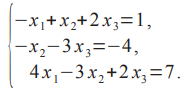


In [285]:
import numpy as np
A = np.array([
    [-1, 1, 2],
    [-1, -3, 0],
    [4, -3, 2]
])
B = np.array(
    [1, -4, 7]
).T

In [286]:
sp.Matrix(A)

Matrix([
[-1,  1, 2],
[-1, -3, 0],
[ 4, -3, 2]])

In [287]:
sp.Matrix(B)

Matrix([
[ 1],
[-4],
[ 7]])


- Напиши функцію для вирішення системи матричним методом *(solve не є матричним методом)*
- Напиши функцію для вирішення системи методом Крамера

In [288]:
# Напиши функцію для вирішення системи матричним методом
def solve_inv_matrix(a, b, verbose=False):
    inv_a = np.linalg.inv(a)
    return inv_a.dot(b)

print(f"Вектор рішення: \r\n {solve_inv_matrix(A, B)}")

Вектор рішення: 
 [1.78947368 0.73684211 1.02631579]


In [296]:
# на всяк випадок перевіримо результат
x = solve_inv_matrix(A, B)
list(map(round, [sum(x * A[0, :]), sum(x * A[1, :]), sum(x * A[2, :])]))

[1, -4, 7]

In [289]:
# Напиши функцію для вирішення системи методом Крамера
def solve_cramer(a, b, verbose=False):
    d = np.linalg.det(a)
    a1 = a.copy()
    a1[:, 0] = b
    a2 = a.copy()
    a2[:, 1] = b
    a3 = a.copy()
    a3[:, 2] = b

    return np.array([np.linalg.det(a1)/d, np.linalg.det(a2)/d, np.linalg.det(a3)/d])


print(f"Вектор рішення: \r\n {solve_cramer(A, B)}")

Вектор рішення: 
 [1.78947368 0.73684211 1.02631579]


## Висновок: обидві функції дали однакові результати